<a href="https://colab.research.google.com/github/inhyuk78/pharmacokinetics-modelling/blob/main/one_compartment_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Part 1: One-Compartment IV Bolus - Weighted Fitting**

**One-Compartment IV Bolus:** A drug is administered directly into the bloodstream, with 100% bioavailability and instantaneous entry into the central compartment. The drug is assumed to distribute rapidly and uniformly throughout a single compartment and undergo first-order elimination, whereby the rate of drug removal is proportional to the amount of drug remaining in the body.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

**1.0 Baseline Parameters**

In [65]:
# ----- Baseline parameters -----
D_fixed = 1000.0               # dose, mg
Vd_fixed = 50.0                # volume of distribution, L
k_fixed = 0.10                 # elimination rate constant, 1/hr
C0_fixed = D_fixed / Vd_fixed  # initial concentration, mg/L

# ----- Derived quantities (true values) -----
t_half_true = np.log(2) / k_fixed
Cl_true = k_fixed * Vd_fixed

print(f'Initial concentration (C0): {C0_fixed:.2f} mg/L')
print(f'Half-life (t1/2): {t_half_true:.2f} hr')
print(f'Clearance (Cl): {Cl_true:.2f} L/hr')

Initial concentration (C0): 20.00 mg/L
Half-life (t1/2): 6.93 hr
Clearance (Cl): 5.00 L/hr


**1.1 Baseline Model**

In [66]:
def one_compartment(t, C0, k):
    '''C(t) = C0 * exp(-k t), with C0 = D / Vd.
    Fit C0 directly: D and Vd are not separately identifiable from concentrations alone.'''
    return C0 * np.exp(-k * t)

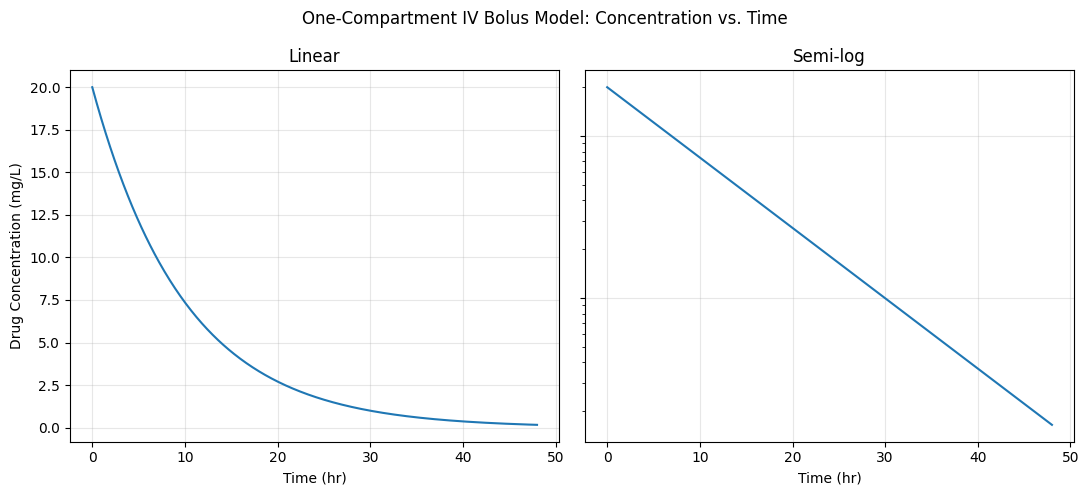

In [67]:
t = np.linspace(0, 48, 500)  # 0 to 48 hours
C = one_compartment(t, C0_fixed, k_fixed)

fig, axs = plt.subplots(1, 2, figsize=(11,5))
fig.suptitle('One-Compartment IV Bolus Model: Concentration vs. Time')

axs[0].plot(t, C)
axs[0].set_title('Linear')

axs[1].plot(t, C)
axs[1].set_yscale('log')
axs[1].set_title('Semi-log')

for ax in axs:
  ax.set(xlabel='Time (hr)', ylabel='Drug Concentration (mg/L)')
  ax.grid(True, alpha=0.3)
  ax.label_outer()

plt.tight_layout()
plt.show()

**1.2 Sensitivity Analysis: Effect of k and dose**

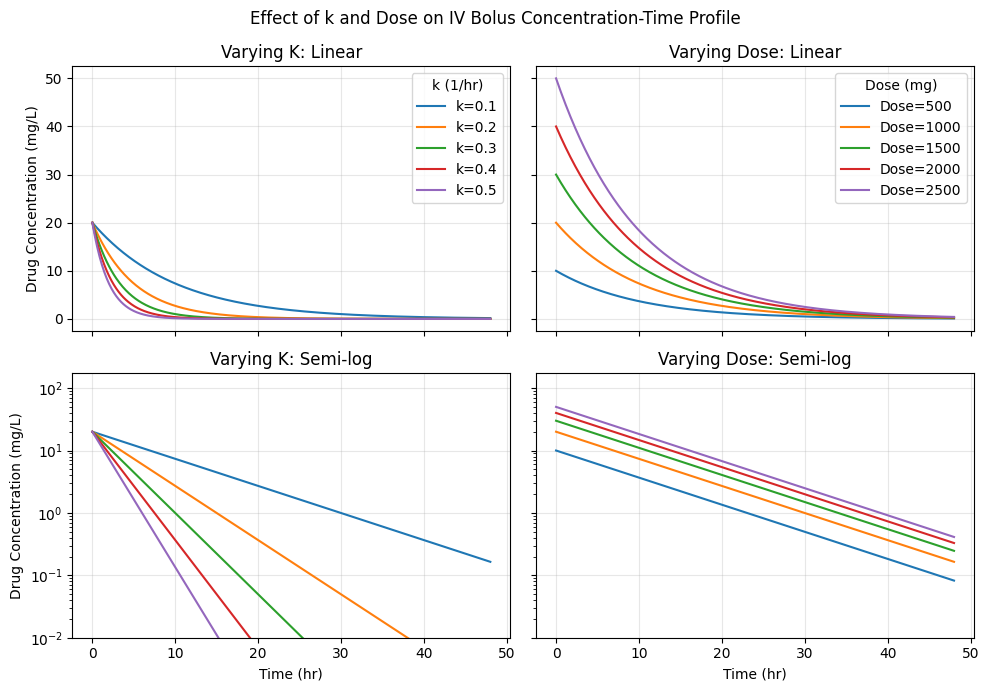

In [68]:
D_values = [500, 1000, 1500, 2000, 2500]  # dose, mg
k_values = [0.1, 0.2, 0.3, 0.4, 0.5]      # eliminiation constant, 1/hr

fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey='row')
fig.suptitle('Effect of k and Dose on IV Bolus Concentration-Time Profile')

# Column 0: vary k (dose and Vd fixed)
for k_val in k_values:
  C = one_compartment(t, C0_fixed, k_val)
  axs[0,0].plot(t, C, label=f'k={k_val}')
  axs[1,0].plot(t, C)

# Column 1: vary dose (k and Vd fixed)
for D_val in D_values:
  C = one_compartment(t, D_val / Vd_fixed, k_fixed)
  axs[0,1].plot(t, C, label=f'Dose={D_val}')
  axs[1,1].plot(t, C)

axs[0,0].set_title('Varying K: Linear')
axs[0,0].legend(title='k (1/hr)', loc='upper right')
axs[1,0].set_title('Varying K: Semi-log')

axs[0,1].set_title('Varying Dose: Linear')
axs[0,1].legend(title='Dose (mg)', loc='upper right')
axs[1,1].set_title('Varying Dose: Semi-log')

for ax in axs[1]:
  ax.set_yscale('log')
  ax.set_ylim(bottom=1e-2)

for ax in fig.get_axes():
  ax.set(xlabel='Time (hr)', ylabel='Drug Concentration (mg/L)',)
  ax.grid(True, alpha=0.3)
  ax.label_outer()

plt.tight_layout()
plt.show()

**1.3 Simulate Noisy Patient Data**

In [69]:
t_samples = np.array([0.25, 0.5, 1, 2, 4, 6, 8, 12, 24, 48])  # sparse sampling schedule (simulate real patient data), hr
C_true = one_compartment(t_samples, C0_fixed, k_fixed)

np.random.seed(42)
noise_CV = 0.1
noise = np.random.normal(loc=0, scale=noise_CV * C_true)           # in practice, high concentrations noisier than lower concentrations
C_noisy = np.clip(C_true + noise, a_min=0, a_max=None)

**1.4 Weighted Fit and Parameter Recovery**

In [70]:
sigma = noise_CV * np.maximum(C_noisy, 1e-3)   # Estimate each observation's std for weighted fitting, with a small floor to avoid near-zero uncertainty.
true_vals = np.array([C0_fixed, k_fixed])
names = ['C0', 'k']

param, cov = curve_fit(one_compartment, t_samples, C_noisy, sigma=sigma, absolute_sigma=True, bounds=(0, np.inf))
se = np.sqrt(np.diag(cov))
fitted_C0, fitted_k = param

results = pd.DataFrame({'true': true_vals,
                        'fitted': param,
                        'SE': se,
                        'Relative SE (%)': se / param * 100}, index=names)
print(results)

# ----- Derived quantities -----
Vd_fit = D_fixed / fitted_C0
t_half_fit = np.log(2) / fitted_k
Cl_fit = fitted_k * Vd_fit

print(f'\nVd   : fitted {Vd_fit:.1f} L   vs true {Vd_fixed:.1f} L ')
print(f't1/2 : fitted {t_half_fit:.2f} hr vs true {t_half_true:.2f} hr')
print(f'CL   : fitted {Cl_fit:.2f} L/hr vs true {Cl_true:.2f} L/hr')

    true     fitted        SE  Relative SE (%)
C0  20.0  20.804009  0.824881         3.965011
k    0.1   0.100371  0.002252         2.243985

Vd   : fitted 48.1 L   vs true 50.0 L 
t1/2 : fitted 6.91 hr vs true 6.93 hr
CL   : fitted 4.82 L/hr vs true 5.00 L/hr


**1.5 Baseline vs Weighted Fit Model**

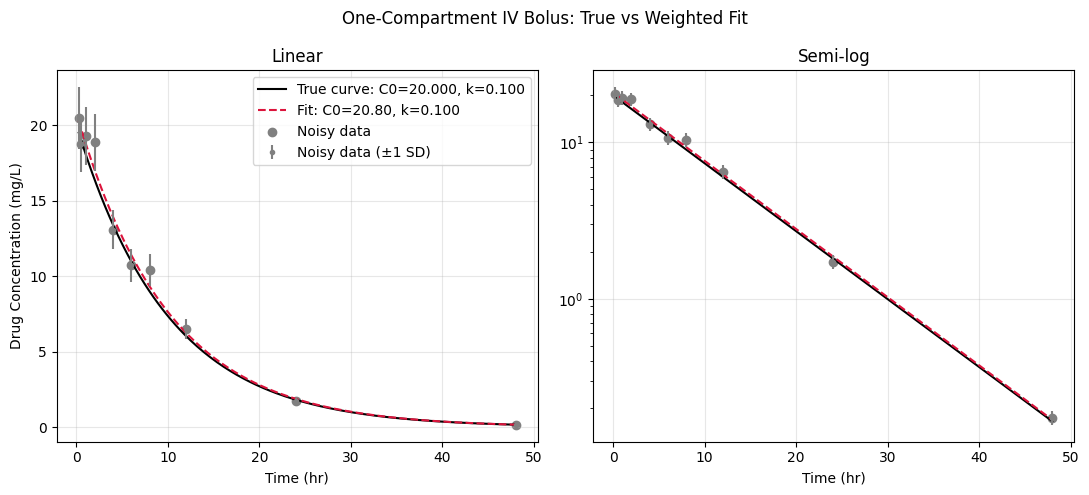

In [71]:
t_smooth = np.linspace(t_samples.min(), t_samples.max(), 200)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('One-Compartment IV Bolus: True vs Weighted Fit')

axs[0].plot(t_smooth, one_compartment(t_smooth, C0_fixed, k_fixed), color='black', label=f'True curve: C0={C0_fixed:.3f}, k={k_fixed:.3f}')
axs[0].plot(t_smooth, one_compartment(t_smooth, fitted_C0, fitted_k), color='crimson', linestyle='--', label=f'Fit: C0={fitted_C0:.2f}, k={fitted_k:.3f}')
axs[0].scatter(t_samples, C_noisy, label='Noisy data', color='gray')
axs[0].errorbar(t_samples, C_noisy, yerr=sigma, fmt='o', color='gray', markersize=3, capsize=0, label='Noisy data (±1 SD)')

axs[1].plot(t_smooth, one_compartment(t_smooth, C0_fixed, k_fixed), color='black', label=f'True curve: k={k_fixed:.3f}, C0={C0_fixed:.3f}')
axs[1].plot(t_smooth, one_compartment(t_smooth, fitted_C0, fitted_k), color='crimson', linestyle='--', label=f'Fit: C0={fitted_C0:.2f}, k={fitted_k:.3f}')
axs[1].scatter(t_samples, C_noisy, label='Noisy data', color='gray')
axs[1].errorbar(t_samples, C_noisy, yerr=sigma, fmt='o', color='gray', markersize=3, capsize=0, label='Noisy data (±1 SD)')

axs[0].set_yscale('linear')
axs[0].set_title('Linear')
axs[0].set_ylabel('Drug Concentration (mg/L)')
axs[0].legend()

axs[1].set_yscale('log')
axs[1].set_title('Semi-log')

for ax in fig.get_axes():
  ax.set(xlabel='Time (hr)')
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()